# Deoxygenation emergent constraints for six regions

Recreates the six-region deoxygenation EC figure for 1965-2021. Reconstruction methods use the same colors and markers as `Intro_figure_deoxygenation_three_depths.ipynb`.

In [1]:
from pathlib import Path
import os
import sys
import warnings

MPLCONFIGDIR = Path('/tmp') / f'matplotlib-{os.environ.get("USER", "user")}'
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.rcParams.update({'figure.dpi': 130, 'savefig.dpi': 300, 'font.size': 14})

# Expensive source-data calculations are skipped when valid caches exist.
FORCE_RECOMPUTE = False

In [2]:
def find_analysis_dir(start=Path.cwd().resolve()):
    for parent in (start, *start.parents):
        candidate = parent / 'Analysis'
        if (candidate / 'Python_functions').is_dir():
            return candidate
        if parent.name == 'Analysis' and (parent / 'Python_functions').is_dir():
            return parent
    fallback = Path('/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Analysis')
    if (fallback / 'Python_functions').is_dir():
        return fallback
    raise FileNotFoundError('Could not locate Analysis/Python_functions from the working directory.')


ANALYSIS_DIR = find_analysis_dir()
NOTEBOOK_DIR = Path.cwd().resolve()
PAPER_DIR = NOTEBOOK_DIR
SOURCE_DIR = ANALYSIS_DIR / 'Variability_quantification/Subsampled_o2_variability'
TREND_DIR = SOURCE_DIR / 'Trends'
VARIABILITY_DIR = SOURCE_DIR / 'Basin_dependent_analysis'
CACHE_DIR = Path('/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures/cache_deoxygenation_decadal_ec_potden_en4_1965_2021')
FULLY_SAMPLED_MODELS_DIR = Path('/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures/NETCDF/Fully_sampled_models_annual_o2')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

PYTHON_FUNCTIONS = ANALYSIS_DIR / 'Python_functions'
if str(PYTHON_FUNCTIONS) not in sys.path:
    sys.path.append(str(PYTHON_FUNCTIONS))

from emergent_constraint_tests import (
    ECDistribution, build_xgrid, compute_component_pdfs, normalize_pdf,
    quantile_from_pdf,
)

PRODUCTS = [
    'observation-Gouretski(2024)',
    'observation-Ito(2024; NN)',
    'observation-Ito(2024; RF)',
    'observation-Ito(2022; 5 year)',
    'observation-Roach and Bindoff',
    'observation-Olivelli(2026)',
]
PRODUCT_LABELS = [name.replace('observation-', '') for name in PRODUCTS]
OBSERVATION_COLORS = ['blue', 'green', 'red', 'purple', '#D55E00', '#009E73']
OBSERVATION_MARKERS = ['s', '^', 'o', 'v', 'P', 'X']
PRODUCT_COLORS = dict(zip(PRODUCT_LABELS, OBSERVATION_COLORS))
PRODUCT_MARKERS = dict(zip(PRODUCT_LABELS, OBSERVATION_MARKERS))
BASIN_INDICES = list(range(7))
BASINS = ['Global', 'Atlantic', 'Pacific', 'Indian', 'Southern',
          'North Atlantic', 'North Pacific']
DEPTH_CONFIGS = [
    {'depth_label': 'Upper 2000 m', 'depth_range': [0, 2000]},
    {'depth_label': 'Below 2000 m', 'depth_range': [2000, None]},
]
CI = 0.95
MIXTURE_CI = 0.95
MIN_TREND_YEARS = 20
REQUIRE_SIGNIFICANT_POSITIVE_SLOPE = True


In [3]:
def valid_trend_ec(ec, max_abs_bound=15.0):
    if ec is None:
        return False, 'none'
    values = [ec.get('x_ec'), ec.get('x_lo'), ec.get('x_hi')]
    if not np.all(np.isfinite(values)):
        return False, 'non-finite estimate or bounds'
    if not ec['x_lo'] < ec['x_ec'] < ec['x_hi']:
        return False, 'bounds do not bracket estimate'
    if abs(ec['x_lo']) >= max_abs_bound or abs(ec['x_hi']) >= max_abs_bound:
        return False, f'bound outside (-{max_abs_bound:g}, {max_abs_bound:g})'
    return True, 'ok'


def apply_significant_positive_slope_flag(table, valid_column):
    if not REQUIRE_SIGNIFICANT_POSITIVE_SLOPE:
        return table
    table = table.copy()
    sigpos = (table['p'] < 0.05) & (table['slope'] > 0)
    fail = table[valid_column] & ~sigpos
    table.loc[fail, valid_column] = False
    table.loc[fail, 'flag'] = 'not p<0.05 and slope>0'
    return table


def valid_variability_ec(ec, physical_min=0.0, max_width_factor=3.0):
    if ec is None:
        return False, 'none'
    values = [ec.get('x_ec'), ec.get('x_lo'), ec.get('x_hi')]
    if not np.all(np.isfinite(values)):
        return False, 'non-finite estimate or bounds'
    if not ec['x_lo'] < ec['x_ec'] < ec['x_hi']:
        return False, 'bounds do not bracket estimate'
    if physical_min is not None and ec['x_lo'] < physical_min:
        return False, f'lower bound below physical_min={physical_min}'
    relative_width = ((ec['x_hi'] - ec['x_lo']) / abs(ec['x_ec'])
                      if ec['x_ec'] != 0 else np.inf)
    if relative_width > max_width_factor:
        return False, f'relative width {relative_width:.2g} exceeds {max_width_factor}'
    return True, 'ok'



def direct_full_ec_from_gapfilled(gapfilled, full, observed_gapfilled, ci=CI):
    gapfilled = np.asarray(gapfilled, dtype=float)
    full = np.asarray(full, dtype=float)
    mask = np.isfinite(gapfilled) & np.isfinite(full)
    x = gapfilled[mask]
    y = full[mask]
    if len(x) < 3:
        return None
    from scipy.stats import linregress, t as tdist
    fit = linregress(x, y)
    if not np.isfinite(fit.slope):
        return None
    yhat = fit.intercept + fit.slope * x
    dof = len(x) - 2
    sxx = np.sum((x - np.mean(x)) ** 2)
    if dof <= 0 or sxx <= 0:
        return None
    s_err = np.sqrt(np.sum((y - yhat) ** 2) / dof)
    tval = tdist.ppf(1 - (1 - ci) / 2, dof)
    se = s_err * np.sqrt(1 / len(x) + (observed_gapfilled - np.mean(x)) ** 2 / sxx)
    ec = fit.intercept + fit.slope * observed_gapfilled
    return {
        'x_ec': float(ec),
        'x_lo': float(ec - tval * se),
        'x_hi': float(ec + tval * se),
        'obs_y': float(observed_gapfilled),
        'rvalue': fit.rvalue,
        'pvalue': fit.pvalue,
        'slope': fit.slope,
        'intercept': fit.intercept,
    }

def mixture_from_rows(rows, valid_column, physical_min=None, ngrid=6000,
                      component='skewnormal'):
    retained = rows.loc[rows[valid_column]].copy()
    distributions = [
        ECDistribution(
            label=row['product'], ec=float(row['ec']), lower=float(row['lo']),
            upper=float(row['hi']), color=PRODUCT_COLORS[row['product']], weight=1.0,
        )
        for _, row in retained.iterrows()
    ]
    if not distributions:
        return dict(ec=np.nan, lo=np.nan, hi=np.nan, mean=np.nan,
                    xgrid=np.array([]), pdf=np.array([]), n_retained=0)
    xgrid = build_xgrid(distributions, physical_min=physical_min, ngrid=ngrid)
    pdfs, _ = compute_component_pdfs(xgrid, distributions, ci=CI, component=component)
    pdf = normalize_pdf(xgrid, np.mean(pdfs, axis=0))
    alpha = 1.0 - MIXTURE_CI
    return dict(
        ec=quantile_from_pdf(xgrid, pdf, 0.50),
        lo=quantile_from_pdf(xgrid, pdf, alpha / 2),
        hi=quantile_from_pdf(xgrid, pdf, 1 - alpha / 2),
        mean=float(np.trapz(xgrid * pdf, xgrid)),
        xgrid=xgrid, pdf=pdf, n_retained=len(distributions),
    )


def build_mixture_table(ec_table, valid_column, physical_min=None):
    rows = []
    for (depth_label, basin), group in ec_table.groupby(['depth_label', 'basin'], sort=False):
        mix = mixture_from_rows(group, valid_column, physical_min=physical_min)
        valid_gapfilled = group.loc[group[valid_column], 'gapfilled'].to_numpy(float)
        gapfilled_median = np.nanmedian(valid_gapfilled) if len(valid_gapfilled) else np.nan
        rows.append({
            'depth_label': depth_label, 'basin': basin,
            'gapfilled_median': gapfilled_median,
            'gapfilled_min': np.nanmin(valid_gapfilled) if len(valid_gapfilled) else np.nan,
            'gapfilled_max': np.nanmax(valid_gapfilled) if len(valid_gapfilled) else np.nan,
            'ec': mix['ec'], 'lo': mix['lo'], 'hi': mix['hi'], 'mean': mix['mean'],
            'ec_minus_gapfilled_median': mix['ec'] - gapfilled_median,
            'ec_to_gapfilled_median_ratio': (
                mix['ec'] / gapfilled_median
                if np.isfinite(gapfilled_median) and gapfilled_median != 0 else np.nan
            ),
            'mixture_xgrid': mix['xgrid'], 'mixture_pdf': mix['pdf'],
            'n_retained': mix['n_retained'],
        })
    return pd.DataFrame(rows)


In [4]:
# Load the cached 1965-2021 regional deoxygenation EC results.
TREND_CACHE = CACHE_DIR / 'trend_product_ec_6_products_olivelli_lonfix_potden_en4_1965_2021_v3.csv'
trend_ec = pd.read_csv(TREND_CACHE)
trend_ec['valid_for_plot'] = trend_ec['valid_for_plot'].astype(str).str.lower().eq('true')
trend_ec = apply_significant_positive_slope_flag(trend_ec, 'valid_for_plot')

# Match reconstruction-method styling in Intro_figure_deoxygenation_three_depths.
INTRO_STYLES = {
    'Ito(2022; 5 year)': {'color': '#0072B2', 'marker': 's'},
    'Ito(2024; NN)': {'color': '#009E73', 'marker': '^'},
    'Ito(2024; RF)': {'color': '#D55E00', 'marker': 'o'},
    'Gouretski(2024)': {'color': '#CC79A7', 'marker': 'D'},
    'Roach and Bindoff': {'color': '#E69F00', 'marker': 'P'},
    'Olivelli(2026)': {'color': '#7B2CBF', 'marker': 'X'},
}
PRODUCT_COLORS = {name: style['color'] for name, style in INTRO_STYLES.items()}
PRODUCT_MARKERS = {name: style['marker'] for name, style in INTRO_STYLES.items()}

trend_mixture = build_mixture_table(trend_ec, 'valid_for_plot', physical_min=None)
print(f'Loaded {len(trend_ec)} product estimates from {TREND_CACHE}')
display(trend_ec.head(), trend_mixture.head())


/tmp/ipykernel_372126/2000756202.py:96: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean=float(np.trapz(xgrid * pdf, xgrid)),


Loaded 84 product estimates from /scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures/cache_deoxygenation_decadal_ec_potden_en4_1965_2021/trend_product_ec_6_products_olivelli_lonfix_potden_en4_1965_2021_v3.csv


,depth_label,basin_index,basin,product,gapfilled,ec,lo,hi,ec_minus_gapfilled,ec_to_gapfilled_ratio,r,p,slope,intercept,valid_for_plot,flag,calculation_version
0,Upper 2000 m,0,Global,Gouretski(2024),0.584991,0.636214,0.556720,0.715708,0.051223,1.087561,0.954837,1.111222e-07,1.056565,0.018133,True,ok,5_products_lonfix_potden_en4_1965_2021_v2_dyna...
1,Upper 2000 m,0,Global,Ito(2024; NN),0.856919,0.525029,0.242449,0.807609,-0.331890,0.612694,0.541128,4.568655e-02,0.479654,0.114005,True,ok,5_products_lonfix_potden_en4_1965_2021_v2_dyna...
2,Upper 2000 m,0,Global,Ito(2024; RF),0.749752,0.941236,0.620101,1.262370,0.191483,1.255395,0.809870,4.466329e-04,1.095604,0.119804,True,ok,5_products_lonfix_potden_en4_1965_2021_v2_dyna...
3,Upper 2000 m,0,Global,Ito(2022; 5 year),0.778405,0.929216,0.767021,1.091410,0.150811,1.193744,0.937454,7.546376e-07,1.169750,0.018677,True,ok,5_products_lonfix_potden_en4_1965_2021_v2_dyna...
4,Upper 2000 m,0,Global,Roach and Bindoff,0.597200,0.150517,0.000667,0.300368,-0.446683,0.252038,-0.378193,1.824313e-01,-0.271824,0.312851,False,not p<0.05 and slope>0,5_products_lonfix_potden_en4_1965_2021_v2_dyna...


,depth_label,basin,gapfilled_median,gapfilled_min,gapfilled_max,ec,lo,hi,mean,ec_minus_gapfilled_median,ec_to_gapfilled_median_ratio,mixture_xgrid,mixture_pdf,n_retained
0,Upper 2000 m,Global,0.749752,0.549519,0.856919,0.666617,0.355950,1.134545,0.722309,-0.083136,0.889116,"[0.0384649411609124, 0.03870296231548045, 0.03...","[0.001862525324944847, 0.0018729290504180085, ...",5
1,Upper 2000 m,Atlantic,0.673516,0.539043,0.714489,0.499117,0.353251,0.692144,0.506646,-0.174399,0.741062,"[0.24602823112222777, 0.2461251753755998, 0.24...","[0.016307947032186857, 0.016374793167391644, 0...",4
2,Upper 2000 m,Pacific,0.632340,0.518981,0.776323,0.509460,0.180692,0.866582,0.503452,-0.122881,0.805673,"[-0.025251402029695336, -0.025062636005096138,...","[0.004138981781231363, 0.004156696928615845, 0...",4
3,Upper 2000 m,Indian,0.499203,0.339321,0.708935,0.663521,0.240076,1.214510,0.652599,0.164318,1.329162,"[-0.00045215318171801244, -0.00020366505423601...","[1.8708202482656235e-06, 1.8966090872591101e-0...",4
4,Upper 2000 m,Southern,0.690076,0.381954,1.032647,0.946130,0.360801,1.338453,0.853492,0.256054,1.371052,"[0.01866399444926864, 0.018958683680167825, 0....","[2.1151993813412015e-05, 2.1444296388641938e-0...",6


In [5]:
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.crs as ccrs
import basin_masks


def pdf_quantiles(xgrid, pdf, quantiles=(0.025, 0.25, 0.50, 0.75, 0.975)):
    xgrid = np.asarray(xgrid, float)
    pdf = np.asarray(pdf, float)
    mask = np.isfinite(xgrid) & np.isfinite(pdf) & (pdf > 0)
    if mask.sum() < 2:
        return None
    x = xgrid[mask]
    p = pdf[mask]
    order = np.argsort(x)
    x = x[order]
    p = p[order]
    area = np.trapz(p, x)
    if not np.isfinite(area) or area <= 0:
        return None
    p = p / area
    cdf = np.concatenate([[0.0], np.cumsum((p[:-1] + p[1:]) * np.diff(x) / 2)])
    cdf = cdf / cdf[-1]
    return np.interp(quantiles, cdf, x)


def value_quantiles(values):
    values = np.asarray(values, float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return None
    if values.size == 1:
        return np.repeat(values[0], 5)
    return np.nanquantile(values, [0.0, 0.25, 0.50, 0.75, 1.0])


def draw_horizontal_box(ax, stats, y, color='k', height=0.18, face_alpha=0.20,
                        lw=1.2, median_lw=1.7, zorder=5, facecolor='none'):
    if stats is None:
        return
    low, q1, median, q3, high = [float(value) for value in stats]
    if not np.all(np.isfinite([low, q1, median, q3, high])):
        return
    if q3 < q1:
        q1, q3 = q3, q1
    if high < low:
        low, high = high, low
    box_width = max(q3 - q1, 0.0)
    if box_width == 0:
        ax.vlines(median, y - height / 2, y + height / 2,
                  color=color, lw=median_lw, zorder=zorder + 2)
    else:
        rect = plt.Rectangle(
            (q1, y - height / 2), box_width, height,
            facecolor=facecolor, edgecolor=color, alpha=1.0, lw=lw, zorder=zorder,
        )
        ax.add_patch(rect)
        ax.vlines(median, y - height / 2, y + height / 2,
                  color=color, lw=median_lw, zorder=zorder + 2)
    if low < q1:
        ax.hlines(y, low, q1, color=color, lw=lw, zorder=zorder + 1)
    if q3 < high:
        ax.hlines(y, q3, high, color=color, lw=lw, zorder=zorder + 1)
    cap = height * 0.36
    ax.vlines([low, high], y - cap, y + cap, color=color, lw=lw, zorder=zorder + 1)


class BoxplotLegend:
    def __init__(self, facecolor, label):
        self.facecolor = facecolor
        self._label = label

    def get_label(self):
        return self._label


class HandlerBoxplot(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        color = '0.15'
        yc = ydescent + 0.5 * height
        left, right = xdescent + 0.22 * width, xdescent + 0.78 * width
        bottom, box_height = ydescent + 0.2 * height, 0.6 * height
        whisker = Line2D([xdescent, xdescent + width], [yc, yc],
                         color=color, linewidth=1.2, transform=trans)
        caps = [Line2D([x, x], [ydescent + 0.32 * height, ydescent + 0.68 * height],
                       color=color, linewidth=1.2, transform=trans)
                for x in (xdescent, xdescent + width)]
        box = Rectangle((left, bottom), right - left, box_height,
                        facecolor=orig_handle.facecolor, edgecolor=color,
                        linewidth=1.2, transform=trans)
        median = Line2D([xdescent + 0.5 * width] * 2, [bottom, bottom + box_height],
                        color=color, linewidth=1.5, transform=trans)
        return [whisker, *caps, box, median]



def panel_xlim(product_table, mixture_table, valid_column, include_zero,
               xlim_source='all'):
    values = []
    if include_zero:
        values.append(0.0)
    if xlim_source == 'mixture_ci':
        for column in ['lo', 'hi', 'gapfilled_min', 'gapfilled_max']:
            values.extend(mixture_table[column].replace([np.inf, -np.inf], np.nan).dropna())
    else:
        valid = product_table.loc[product_table[valid_column]]
        for column in ['gapfilled', 'lo', 'ec', 'hi']:
            values.extend(valid[column].replace([np.inf, -np.inf], np.nan).dropna())
        for column in ['gapfilled_min', 'gapfilled_max', 'lo', 'ec', 'hi']:
            values.extend(mixture_table[column].replace([np.inf, -np.inf], np.nan).dropna())
    values = [value for value in values if np.isfinite(value)]
    xmin, xmax = float(np.nanmin(values)), float(np.nanmax(values))
    pad = 0.10 * (xmax - xmin if xmax > xmin else 1.0)
    if xlim_source == 'mixture_ci':
        return xmin - pad, xmax + pad
    lower = xmin - pad if include_zero else max(0.0, xmin - pad)
    return lower, xmax + pad


def annotate_out_of_bounds_ci(ax, lo, hi, y, xmin, xmax, color,
                              fontsize=8, marker_scale=1.0):
    xspan = xmax - xmin
    if not np.isfinite(xspan) or xspan <= 0:
        return
    annotations = []
    if np.isfinite(lo) and lo < xmin:
        annotations.append((xmin + 0.045 * xspan, lo, 'left'))
    if np.isfinite(hi) and hi > xmax:
        annotations.append((xmax - 0.015 * xspan, hi, 'right'))
    for x_text, value, ha in annotations:
        ax.text(
            x_text, y, f'{value:.2f}', ha=ha, va='center', color=color,
            fontsize=fontsize, fontweight='bold', clip_on=False, zorder=20,
            bbox=dict(facecolor='white', edgecolor=color, alpha=0.85,
                      linewidth=0.6 * marker_scale, pad=1),
        )


def plot_panel(ax, product_table, mixture_table, depth_label, valid_column,
               xlabel, panel_label, include_zero=False, basins_to_plot=None,
               show_yticklabels=True, row_spacing=1.0, text_fontsize=14,
               marker_scale=1.0, box_height=0.20, xlim_source='all',
               annotate_out_of_bounds_product=None, xlim_override=None,
               annotate_out_of_bounds_mixture=False, show_individual_products=False):
    if basins_to_plot is None:
        basins_to_plot = BASINS
    panel_products = product_table.loc[
        (product_table['depth_label'] == depth_label) &
        (product_table['basin'].isin(basins_to_plot))
    ]
    panel_mixture = mixture_table.loc[
        (mixture_table['depth_label'] == depth_label) &
        (mixture_table['basin'].isin(basins_to_plot))
    ]
    xmin, xmax = panel_xlim(
        panel_products, panel_mixture, valid_column, include_zero,
        xlim_source=xlim_source,
    )
    if xlim_override is not None:
        xmin, xmax = xlim_override
    label_x = xmax - 0.02 * (xmax - xmin)
    y_base = np.arange(len(basins_to_plot))[::-1] * row_spacing
    offsets = np.array([0.375, 0.225, 0.075, -0.075, -0.225, -0.375])
    if include_zero:
        ax.axvline(0, color='0.25', lw=1.2, ls='--', zorder=0)

    for basin_index, basin in enumerate(basins_to_plot):
        y0 = y_base[basin_index]
        ec_y = y0
        gap_y = y0
        ax.axhline(y0, color='0.90', lw=0.8, zorder=0)
        mix_rows = panel_mixture.loc[panel_mixture['basin'] == basin]
        if mix_rows.empty:
            continue
        mix = mix_rows.iloc[0]
        if np.all(np.isfinite([mix['lo'], mix['ec'], mix['hi']])):
            draw_horizontal_box(
                ax, pdf_quantiles(mix['mixture_xgrid'], mix['mixture_pdf']), ec_y,
                color='k', height=box_height, face_alpha=0.18,
                lw=1.1 * marker_scale, median_lw=1.8 * marker_scale, zorder=6,
            )
            ax.plot(mix['gapfilled_median'], gap_y, marker='o', mfc='white',
                    mec='k', mew=1.2 * marker_scale, ms=5.5 * marker_scale, zorder=7)
            if annotate_out_of_bounds_mixture:
                annotate_out_of_bounds_ci(
                    ax, mix['lo'], mix['hi'], ec_y + 0.18, xmin, xmax, '0.25',
                    fontsize=text_fontsize, marker_scale=marker_scale,
                )
        ratio = mix['ec_to_gapfilled_median_ratio']
        if np.isfinite(ratio):
            delta = mix['ec_minus_gapfilled_median']
            ax.text(label_x, y0 + 0.33, f'{ratio:.2f}x, {delta:+.2f}',
                    ha='right', va='center', fontsize=text_fontsize, fontweight='bold',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1))

        if not show_individual_products:
            continue
        for product_index, product in enumerate(PRODUCT_LABELS):
            rows = panel_products.loc[
                (panel_products['basin'] == basin) & (panel_products['product'] == product)
            ]
            if rows.empty:
                continue
            row = rows.iloc[0]
            if not row[valid_column]:
                continue
            y = y0 + offsets[product_index]
            color = PRODUCT_COLORS[product]
            marker = PRODUCT_MARKERS[product]
            ax.plot([row['gapfilled'], row['ec']], [y, y], color=color,
                    lw=0.8 * marker_scale, alpha=0.35)
            ax.plot(row['gapfilled'], y, marker=marker, mfc='white', mec=color,
                    mew=1.3 * marker_scale, ms=5.8 * marker_scale, zorder=4)
            ax.hlines(y, np.clip(row['lo'], xmin, xmax), np.clip(row['hi'], xmin, xmax),
                      color=color, lw=1.8 * marker_scale, zorder=3)
            ax.plot(row['ec'], y, marker=marker, color=color, ms=6 * marker_scale, zorder=5)
            annotate_products = annotate_out_of_bounds_product
            if annotate_products is not None and isinstance(annotate_products, str):
                annotate_products = {annotate_products}
            if annotate_products is None or product in annotate_products:
                annotation_y = y
                if (
                    depth_label == 'Below 2000 m' and basin == 'Pacific' and
                    product == 'Ito(2024; NN)' and np.isfinite(row['hi']) and row['hi'] > xmax
                ):
                    annotation_y = y0 + 0.03
                annotate_out_of_bounds_ci(
                    ax, row['lo'], row['hi'], annotation_y, xmin, xmax, color,
                    fontsize=text_fontsize, marker_scale=marker_scale,
                )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.6, (len(basins_to_plot) - 1) * row_spacing + 0.6)
    basin_display_labels = {
        'Atlantic': 'Tropical Atlantic',
        'Pacific': 'Tropical Pacific',
        'Indian': 'Tropical Indian',
        'North Atlantic': 'North Atlantic',
        'North Pacific': 'North Pacific',
    }
    ax.set_yticks(y_base)
    ax.set_yticklabels([basin_display_labels.get(basin, basin) for basin in basins_to_plot])
    if not show_yticklabels:
        ax.tick_params(labelleft=False)
    ax.set_xlabel(xlabel)
    ax.set_title(f'{panel_label}. {depth_label}', loc='center', fontweight='bold')
    ax.grid(axis='x', ls='--', alpha=0.35)


def plot_gapfilled_and_ec_panel(ax, product_table, depth_label,
                                xlabel, panel_label, include_zero=False,
                                basins_to_plot=None, show_yticklabels=True,
                                row_spacing=1.0, box_height=0.22):
    """Plot paired boxplots and product markers for gap-filled and EC estimates."""
    if basins_to_plot is None:
        basins_to_plot = BASINS
    panel_products = product_table.loc[
        (product_table['depth_label'] == depth_label) &
        (product_table['basin'].isin(basins_to_plot))
    ]
    gapfilled = panel_products['gapfilled'].replace([np.inf, -np.inf], np.nan).dropna()
    ec_values = panel_products['ec'].replace([np.inf, -np.inf], np.nan).dropna()
    values = gapfilled.to_list() + ec_values.to_list()
    if include_zero:
        values.append(0.0)
    xmin, xmax = float(np.min(values)), float(np.max(values))
    pad = 0.10 * (xmax - xmin if xmax > xmin else 1.0)
    xmin = xmin - pad if include_zero else max(0.0, xmin - pad)
    xmax += pad
    y_base = np.arange(len(basins_to_plot))[::-1] * row_spacing
    if include_zero:
        ax.axvline(0, color='0.25', lw=1.2, ls='--', zorder=0)

    for basin_index, basin in enumerate(basins_to_plot):
        y = y_base[basin_index]
        gap_y = y + 0.16
        ec_y = y - 0.16
        ax.axhline(y, color='0.90', lw=0.8, zorder=0)
        basin_values = panel_products.loc[
            panel_products['basin'] == basin, 'gapfilled'
        ].to_numpy(float)
        draw_horizontal_box(
            ax, value_quantiles(basin_values), gap_y, color='0.15',
            facecolor='#DCEEF8', height=box_height, lw=1.5,
            median_lw=2.2, zorder=6,
        )
        basin_ec_values = panel_products.loc[
            panel_products['basin'] == basin, 'ec'
        ].to_numpy(float)
        draw_horizontal_box(
            ax, value_quantiles(basin_ec_values), ec_y, color='0.15',
            facecolor='#FBE3D4', height=box_height, lw=1.5,
            median_lw=2.2, zorder=6,
        )
        finite_gap = basin_values[np.isfinite(basin_values)]
        finite_ec = basin_ec_values[np.isfinite(basin_ec_values)]
        if finite_gap.size and finite_ec.size:
            gap_median = float(np.median(finite_gap))
            ec_median = float(np.median(finite_ec))
            ratio = ec_median / gap_median if gap_median != 0 else np.nan
            delta = ec_median - gap_median
            if np.isfinite(ratio):
                ax.text(
                    xmax - 0.02 * (xmax - xmin), y + 0.43,
                    f'{ratio:.2f}x, {delta:+.2f}', ha='right', va='center',
                    fontsize=10, fontweight='bold', zorder=12,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.78, pad=1),
                )
        for product in PRODUCT_LABELS:
            rows = panel_products.loc[
                (panel_products['basin'] == basin) &
                (panel_products['product'] == product)
            ]
            if rows.empty:
                continue
            row = rows.iloc[0]
            color = PRODUCT_COLORS[product]
            marker = PRODUCT_MARKERS[product]
            for value, marker_y in [(row['gapfilled'], gap_y), (row['ec'], ec_y)]:
                if np.isfinite(value):
                    ax.plot(
                        value, marker_y, marker=marker, color=color,
                        mec='0.20', mew=0.8, ms=7.5, lw=0, zorder=9,
                    )

    basin_display_labels = {
        'Atlantic': 'Tropical Atlantic',
        'Pacific': 'Tropical Pacific',
        'Indian': 'Tropical Indian',
        'North Atlantic': 'North Atlantic',
        'North Pacific': 'North Pacific',
    }
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.6, (len(basins_to_plot) - 1) * row_spacing + 0.6)
    ax.set_yticks(y_base)
    ax.set_yticklabels([basin_display_labels.get(basin, basin)
                        for basin in basins_to_plot])
    if not show_yticklabels:
        ax.tick_params(labelleft=False)
    ax.set_xlabel(xlabel)
    ax.set_title(f'{panel_label}. {depth_label}', loc='center', fontweight='bold')
    ax.grid(axis='x', ls='--', alpha=0.35)


def plot_mixture_ec_depth_panel(ax, product_table, mixture_table, depth_label,
                                valid_column, xlabel, panel_label,
                                include_zero=False, basins_to_plot=None,
                                show_yticklabels=True, row_spacing=1.15,
                                box_height=0.35 * 1.15):
    """Plot gap-filled empirical boxes beside skew-normal mixture EC boxes."""
    if basins_to_plot is None:
        basins_to_plot = BASINS
    panel_products = product_table.loc[
        (product_table['depth_label'] == depth_label) &
        product_table['basin'].isin(basins_to_plot)
    ]
    panel_mixture = mixture_table.loc[
        (mixture_table['depth_label'] == depth_label) &
        mixture_table['basin'].isin(basins_to_plot)
    ]
    finite_values = panel_products['gapfilled'].replace(
        [np.inf, -np.inf], np.nan
    ).dropna().tolist()
    for _, mix in panel_mixture.iterrows():
        stats = pdf_quantiles(mix['mixture_xgrid'], mix['mixture_pdf'])
        if stats is not None:
            finite_values.extend([stats[0], stats[-1]])
    if include_zero:
        finite_values.append(0.0)
    data_min, data_max = float(np.min(finite_values)), float(np.max(finite_values))
    data_span = data_max - data_min if data_max > data_min else 1.0
    xmin = data_min - 0.07 * data_span
    if not include_zero:
        xmin = max(0.0, xmin)
    xmax = data_max + 0.38 * data_span
    xspan = xmax - xmin
    y_base = np.arange(len(basins_to_plot))[::-1] * row_spacing
    if include_zero:
        ax.axvline(0, color='0.25', lw=1.2, ls='--', zorder=0)

    for basin_index, basin in enumerate(basins_to_plot):
        y0 = y_base[basin_index]
        gap_y, ec_y = y0 + 0.22, y0 - 0.22
        ax.axhline(y0, color='0.88', lw=0.8, zorder=0)
        rows = panel_products.loc[panel_products['basin'] == basin]
        mix_rows = panel_mixture.loc[panel_mixture['basin'] == basin]
        if rows.empty or mix_rows.empty:
            continue
        mix = mix_rows.iloc[0]
        gap_values = rows['gapfilled'].to_numpy(float)
        mixture_stats = pdf_quantiles(mix['mixture_xgrid'], mix['mixture_pdf'])
        draw_horizontal_box(
            ax, value_quantiles(gap_values), gap_y, color='0.15',
            facecolor='#DCEEF8', height=box_height, lw=1.6,
            median_lw=2.2, zorder=6,
        )
        draw_horizontal_box(
            ax, mixture_stats, ec_y, color='0.15',
            facecolor='#FBE3D4', height=box_height, lw=1.6,
            median_lw=2.2, zorder=6,
        )
        for product in PRODUCT_LABELS:
            product_rows = rows.loc[rows['product'] == product]
            if product_rows.empty:
                continue
            row = product_rows.iloc[0]
            for column, marker_y in [('gapfilled', gap_y), ('ec', ec_y)]:
                value = row[column]
                if not np.isfinite(value):
                    continue
                retained = column == 'gapfilled' or bool(row[valid_column])
                ax.plot(
                    value, marker_y, marker=PRODUCT_MARKERS[product],
                    color=PRODUCT_COLORS[product] if retained else 'none',
                    mec=PRODUCT_COLORS[product], mew=1.0, ms=7.0,
                    lw=0, alpha=1.0 if retained else 0.65, zorder=9,
                )
        gap_median = float(np.nanmedian(gap_values))
        mixture_median = mixture_stats[2] if mixture_stats is not None else np.nan
        if np.isfinite(gap_median) and np.isfinite(mixture_median):
            ratio = mixture_median / gap_median if gap_median != 0 else np.nan
            delta = mixture_median - gap_median
            if np.isfinite(ratio):
                percent_change = 100 * (ratio - 1)
                ax.text(
                    xmax - 0.02 * xspan, y0,
                    f'{delta:+.2f} ({percent_change:.0f}%)', ha='right', va='center',
                    fontsize=10, fontweight='bold', zorder=12,
                    color='#2166AC' if delta < 0 else '#B2182B',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.80, pad=1),
                )

    basin_display_labels = {
        'Atlantic': 'Tropical\nAtlantic',
        'Pacific': 'Tropical\nPacific',
        'Indian': 'Tropical\nIndian',
        'North Atlantic': 'North\nAtlantic',
        'North Pacific': 'North\nPacific',
    }
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.65, (len(basins_to_plot) - 1) * row_spacing + 0.65)
    ax.set_yticks(y_base)
    ax.set_yticklabels([basin_display_labels.get(basin, basin)
                        for basin in basins_to_plot])
    if not show_yticklabels:
        ax.tick_params(labelleft=False)
    ax.set_xlabel(xlabel)
    ax.set_title(f'{panel_label}. {depth_label}', fontweight='bold')
    ax.grid(axis='x', ls='--', alpha=0.35)


def plot_combined_metric_panel(ax, product_table, xlabel, panel_label, title,
                               include_zero=False, basins_to_plot=None,
                               show_yticklabels=True, row_spacing=1.7,
                               box_height=0.14):
    """Combine both depth ranges in one regional metric panel."""
    if basins_to_plot is None:
        basins_to_plot = BASINS
    panel_products = product_table.loc[
        product_table['basin'].isin(basins_to_plot)
    ]
    finite_values = []
    for column in ['gapfilled', 'ec']:
        finite_values.extend(
            panel_products[column].replace([np.inf, -np.inf], np.nan).dropna().tolist()
        )
    if include_zero:
        finite_values.append(0.0)
    xmin, xmax = float(np.min(finite_values)), float(np.max(finite_values))
    data_span = xmax - xmin if xmax > xmin else 1.0
    left_pad = 0.07 * data_span
    right_pad = 0.55 * data_span
    xmin = xmin - left_pad if include_zero else max(0.0, xmin - left_pad)
    xmax += right_pad
    xspan = xmax - xmin
    y_base = np.arange(len(basins_to_plot))[::-1] * row_spacing
    depth_offsets = {'Upper 2000 m': 0.34, 'Below 2000 m': -0.34}
    estimate_offsets = {'gapfilled': 0.09, 'ec': -0.09}
    depth_short_labels = {'Upper 2000 m': 'Upper', 'Below 2000 m': 'Below'}
    if include_zero:
        ax.axvline(0, color='0.25', lw=1.2, ls='--', zorder=0)

    for basin_index, basin in enumerate(basins_to_plot):
        y0 = y_base[basin_index]
        ax.axhline(y0, color='0.82', lw=0.9, zorder=0)
        for depth_label, depth_offset in depth_offsets.items():
            rows = panel_products.loc[
                (panel_products['basin'] == basin) &
                (panel_products['depth_label'] == depth_label)
            ]
            gap_values = rows['gapfilled'].to_numpy(float)
            ec_values = rows['ec'].to_numpy(float)
            depth_y = y0 + depth_offset
            gap_y = depth_y + estimate_offsets['gapfilled']
            ec_y = depth_y + estimate_offsets['ec']
            draw_horizontal_box(
                ax, value_quantiles(gap_values), gap_y, color='0.15',
                facecolor='#DCEEF8', height=box_height, lw=1.3,
                median_lw=1.9, zorder=6,
            )
            draw_horizontal_box(
                ax, value_quantiles(ec_values), ec_y, color='0.15',
                facecolor='#FBE3D4', height=box_height, lw=1.3,
                median_lw=1.9, zorder=6,
            )
            for product in PRODUCT_LABELS:
                product_rows = rows.loc[rows['product'] == product]
                if product_rows.empty:
                    continue
                row = product_rows.iloc[0]
                for column, marker_y in [('gapfilled', gap_y), ('ec', ec_y)]:
                    value = row[column]
                    if np.isfinite(value):
                        ax.plot(
                            value, marker_y, marker=PRODUCT_MARKERS[product],
                            color=PRODUCT_COLORS[product], mec='0.20', mew=0.7,
                            ms=6.5, lw=0, zorder=9,
                        )
            finite_gap = gap_values[np.isfinite(gap_values)]
            finite_ec = ec_values[np.isfinite(ec_values)]
            if finite_gap.size and finite_ec.size:
                gap_median = float(np.median(finite_gap))
                ec_median = float(np.median(finite_ec))
                ratio = ec_median / gap_median if gap_median != 0 else np.nan
                delta = ec_median - gap_median
                if np.isfinite(ratio):
                    ax.text(
                        xmax - 0.02 * xspan, depth_y,
                        f'{depth_short_labels[depth_label]}: {ratio:.2f}x, {delta:+.2f}',
                        ha='right', va='center', fontsize=8.5, fontweight='bold',
                        zorder=12,
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.80, pad=1),
                    )

    basin_display_labels = {
        'Atlantic': 'Tropical Atlantic',
        'Pacific': 'Tropical Pacific',
        'Indian': 'Tropical Indian',
        'North Atlantic': 'North\nAtlantic',
        'North Pacific': 'North\nPacific',
    }
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.75, (len(basins_to_plot) - 1) * row_spacing + 0.75)
    ax.set_yticks(y_base)
    ax.set_yticklabels([basin_display_labels.get(basin, basin)
                        for basin in basins_to_plot])
    if not show_yticklabels:
        ax.tick_params(labelleft=False)
    ax.set_xlabel(xlabel)
    ax.set_title(f'{panel_label}. {title}', loc='center', fontweight='bold')
    ax.grid(axis='x', ls='--', alpha=0.35)


def plot_global_metric_panel(ax, product_table, mixture_table, valid_column,
                             xlabel, panel_label, title, include_zero=False,
                             text_fontsize=14, marker_scale=1.0, box_height=0.18,
                             xlim_source='all', annotate_out_of_bounds_product=None,
                             xlim_lower_bound=None):
    depths_to_plot = [config['depth_label'] for config in DEPTH_CONFIGS]
    panel_products = product_table.loc[
        (product_table['basin'] == 'Global') &
        (product_table['depth_label'].isin(depths_to_plot))
    ]
    panel_mixture = mixture_table.loc[
        (mixture_table['basin'] == 'Global') &
        (mixture_table['depth_label'].isin(depths_to_plot))
    ]
    xmin, xmax = panel_xlim(
        panel_products, panel_mixture, valid_column, include_zero,
        xlim_source=xlim_source,
    )
    if xlim_lower_bound is not None:
        xmin = xlim_lower_bound
    label_x = xmax - 0.02 * (xmax - xmin)
    y_base = np.arange(len(depths_to_plot))[::-1]
    offsets = np.array([0.40, 0.24, 0.08, -0.08, -0.24, -0.40])
    if include_zero:
        ax.axvline(0, color='0.25', lw=1.2, ls='--', zorder=0)

    for depth_index, depth_label in enumerate(depths_to_plot):
        y0 = y_base[depth_index]
        ec_y = y0
        gap_y = y0
        ax.axhline(y0, color='0.90', lw=0.8, zorder=0)
        mix_rows = panel_mixture.loc[panel_mixture['depth_label'] == depth_label]
        if mix_rows.empty:
            continue
        mix = mix_rows.iloc[0]
        if np.all(np.isfinite([mix['lo'], mix['ec'], mix['hi']])):
            draw_horizontal_box(
                ax, pdf_quantiles(mix['mixture_xgrid'], mix['mixture_pdf']), ec_y,
                color='k', height=box_height, face_alpha=0.18,
                lw=1.1 * marker_scale, median_lw=1.8 * marker_scale, zorder=6,
            )
            ax.plot(mix['gapfilled_median'], gap_y, marker='o', mfc='white',
                    mec='k', mew=1.2 * marker_scale, ms=5.5 * marker_scale, zorder=7)
        ratio = mix['ec_to_gapfilled_median_ratio']
        if np.isfinite(ratio):
            delta = mix['ec_minus_gapfilled_median']
            ax.text(label_x, y0 + 0.31, f'{ratio:.2f}x, {delta:+.2f}',
                    ha='right', va='center', fontsize=text_fontsize, fontweight='bold',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1))

        for product_index, product in enumerate(PRODUCT_LABELS):
            rows = panel_products.loc[
                (panel_products['depth_label'] == depth_label) &
                (panel_products['product'] == product)
            ]
            if rows.empty:
                continue
            row = rows.iloc[0]
            if not row[valid_column]:
                continue
            y = y0 + offsets[product_index]
            color = PRODUCT_COLORS[product]
            marker = PRODUCT_MARKERS[product]
            ax.plot([row['gapfilled'], row['ec']], [y, y], color=color,
                    lw=0.8 * marker_scale, alpha=0.30)
            ax.plot(row['gapfilled'], y, marker=marker, mfc='white', mec=color,
                    mew=1.1 * marker_scale, ms=4.6 * marker_scale, zorder=4, alpha=0.60)
            ax.hlines(y, np.clip(row['lo'], xmin, xmax), np.clip(row['hi'], xmin, xmax),
                      color=color, lw=1.5 * marker_scale, zorder=3, alpha=0.70)
            ax.plot(row['ec'], y, marker=marker, color=color, ms=4.8 * marker_scale, zorder=5, alpha=0.75)
            annotate_products = annotate_out_of_bounds_product
            if annotate_products is not None and isinstance(annotate_products, str):
                annotate_products = {annotate_products}
            if annotate_products is None or product in annotate_products:
                annotate_out_of_bounds_ci(
                    ax, row['lo'], row['hi'], y, xmin, xmax, color,
                    fontsize=text_fontsize, marker_scale=marker_scale,
                )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.6, len(depths_to_plot) - 0.4)
    ax.set_yticks(y_base)
    ax.set_yticklabels([label.replace(' ', '\n', 1) for label in depths_to_plot])
    ax.set_xlabel(xlabel)
    ax.set_title(f'{panel_label}. {title}', loc='center', fontweight='bold')
    ax.grid(axis='x', ls='--', alpha=0.35)


REGION_MAP_LABELS = {
    'Atlantic': 'Trop. Atl.',
    'Pacific': 'Trop. Pac.',
    'Indian': 'Trop. Ind.',
    'Southern': 'Southern',
    'North Atlantic': 'Extra. Atl.',
    'North Pacific': 'Extra. Pac.',
}
REGION_MAP_COLORS = dict(zip(
    ['Atlantic', 'Pacific', 'Indian', 'Southern', 'North Atlantic', 'North Pacific'],
    ['#4E79A7', '#59A14F', '#F28E2B', '#76B7B2', '#E15759', '#B07AA1'],
))
REGION_MAP_LABEL_POINTS = {
    'Atlantic': (330, -7),
    'Pacific': (225, -7),
    'Indian': (80, -14),
    'Southern': (180, -55),
    'North Atlantic': (320, 43),
    'North Pacific': (210, 43),
}


def build_six_region_map_field():
    template_path = FULLY_SAMPLED_MODELS_DIR / 'o2_1x1bin_GFDL_ESM4_r1i1p1f1.nc'
    if not template_path.exists():
        template_path = sorted(FULLY_SAMPLED_MODELS_DIR.glob('*.nc'))[0]
    with xr.open_dataset(template_path) as ds:
        variable = 'o2' if 'o2' in ds.data_vars else next(iter(ds.data_vars))
        field = ds[variable]
        for dim in ['time', 'lev', 'depth']:
            if dim in field.dims:
                field = field.isel({dim: 0})
        rename = {}
        if 'x' in field.dims:
            rename['x'] = 'lon'
        if 'y' in field.dims:
            rename['y'] = 'lat'
        if rename:
            field = field.rename(rename)
        field = field.load()
    land_mask = field.where(np.isfinite(field))
    masks = basin_masks.create_basin_mask(land_mask, nbasins=6)
    region = xr.full_like(masks[0], np.nan, dtype=float)
    for index, mask in enumerate(masks, start=1):
        region = region.where(~(mask.fillna(0) > 0), float(index))
    return region


def add_supplementary_region_map(fig, rect, label_fontsize=8.0, title_fontsize=12.0):
    region = build_six_region_map_field()
    projection = ccrs.Robinson(central_longitude=205)
    ax = fig.add_axes(rect, projection=projection)
    cmap = ListedColormap([REGION_MAP_COLORS[basin] for basin in supplementary_basins])
    norm = BoundaryNorm(np.arange(0.5, len(supplementary_basins) + 1.5), cmap.N)
    land = xr.where(np.isfinite(region), np.nan, 1.0)
    land_cmap = ListedColormap(['0.82'])
    ax.pcolormesh(
        land.lon, land.lat, land, cmap=land_cmap, shading='nearest',
        transform=ccrs.PlateCarree(), rasterized=True, zorder=0,
    )
    ax.pcolormesh(
        region.lon, region.lat, region, cmap=cmap, norm=norm, shading='nearest',
        transform=ccrs.PlateCarree(), rasterized=True, zorder=1,
    )
    ax.set_global()
    ax.gridlines(draw_labels=False, linewidth=0.25, color='0.65', alpha=0.45)
    ax.set_title('c. Six analysis regions', fontsize=title_fontsize, fontweight='bold', pad=3)
    try:
        ax.spines['geo'].set_linewidth(0.45)
        ax.spines['geo'].set_edgecolor('0.35')
    except Exception:
        pass
    for basin in supplementary_basins:
        lon, lat = REGION_MAP_LABEL_POINTS[basin]
        ax.text(
            lon, lat, REGION_MAP_LABELS[basin], transform=ccrs.PlateCarree(),
            ha='center', va='center', fontsize=label_fontsize, color='0.10',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.72, pad=0.8),
            zorder=5,
        )
    return ax


LEGEND_LABELS = {
    'Gouretski(2024)': 'Gouretski et al. (2024)',
    'Ito(2024; NN)': 'Ito et al. (2024): Neural network',
    'Ito(2024; RF)': 'Ito et al. (2024): Random forest',
    'Ito(2022; 5 year)': 'Ito (2022)',
    'Roach and Bindoff': 'Roach & Bindoff (2023)',
    'Olivelli(2026)': 'Olivelli et al. (2026)',
}



/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Anaconda/envs/xmip/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


/tmp/ipykernel_372126/2516564736.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(p, x)


/tmp/ipykernel_372126/2516564736.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(p, x)


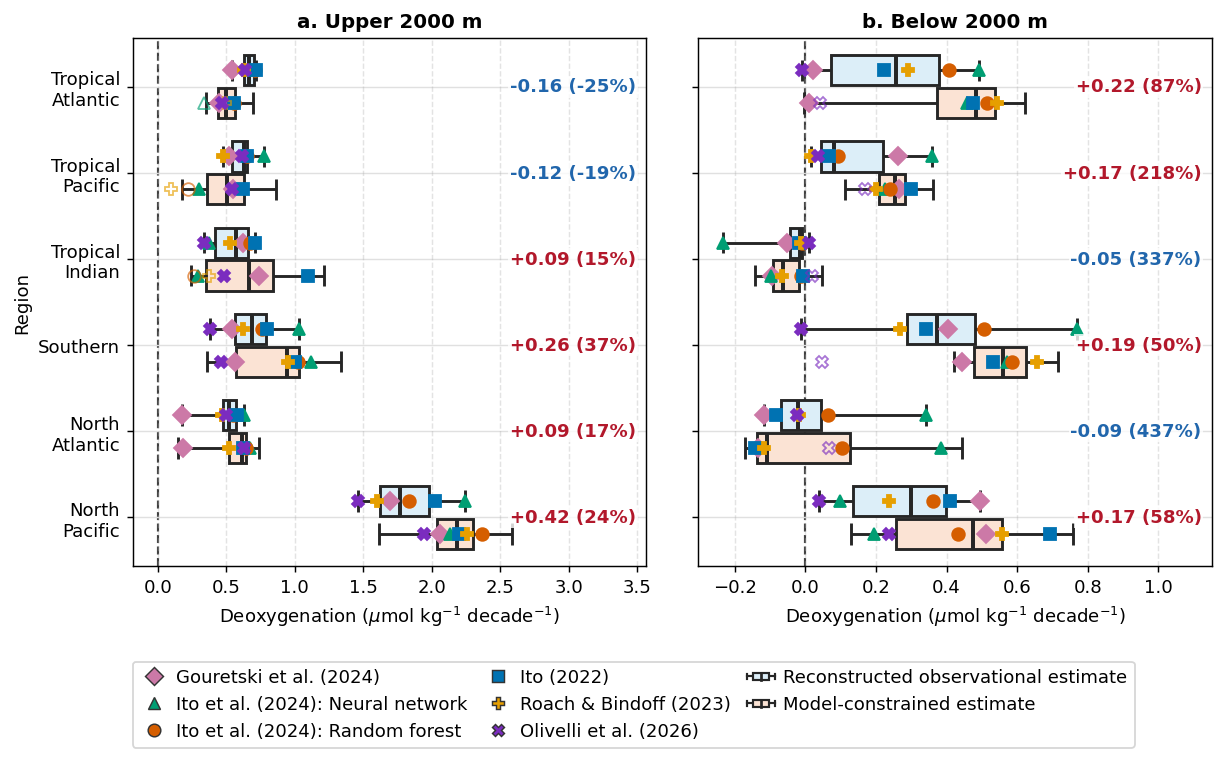

Saved /scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures_p2/Figures/deoxygenation_EC_six_regions.pdf


In [6]:
supplementary_basins = [basin for basin in BASINS if basin != 'Global']
supp_handles = [
    Line2D([0], [0], marker=PRODUCT_MARKERS[label], color=PRODUCT_COLORS[label],
           markeredgecolor='0.20', markeredgewidth=0.8, lw=0, markersize=7,
           label=LEGEND_LABELS.get(label, label))
    for label in PRODUCT_LABELS
]
supp_handles.extend([
    BoxplotLegend('#DCEEF8', 'Reconstructed observational estimate'),
    BoxplotLegend('#FBE3D4', 'Model-constrained estimate'),
])

with plt.rc_context({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
}):
    deoxygenation_fig = plt.figure(figsize=(10, 7))
    deoxygenation_ax_upper = deoxygenation_fig.add_axes([0.15, 0.36, 0.395, 0.58])
    deoxygenation_ax_below = deoxygenation_fig.add_axes(
        [0.585, 0.36, 0.395, 0.58], sharey=deoxygenation_ax_upper
    )
    deoxygenation_axes = [deoxygenation_ax_upper, deoxygenation_ax_below]
    plot_mixture_ec_depth_panel(
        deoxygenation_axes[0], trend_ec, trend_mixture, 'Upper 2000 m',
        'valid_for_plot',
        r'Deoxygenation ($\mu$mol kg$^{-1}$ decade$^{-1}$)', 'a',
        include_zero=True, basins_to_plot=supplementary_basins,
    )
    plot_mixture_ec_depth_panel(
        deoxygenation_axes[1], trend_ec, trend_mixture, 'Below 2000 m',
        'valid_for_plot',
        r'Deoxygenation ($\mu$mol kg$^{-1}$ decade$^{-1}$)', 'b',
        include_zero=True, basins_to_plot=supplementary_basins,
        show_yticklabels=False,
    )
    deoxygenation_label_size = deoxygenation_axes[0].get_yticklabels()[0].get_fontsize()
    for ax in deoxygenation_axes:
        ax.xaxis.label.set_size(deoxygenation_label_size)
    deoxygenation_axes[0].set_ylabel('Region', fontsize=deoxygenation_label_size)
    deoxygenation_fig.legend(
        handles=supp_handles, loc='lower left', bbox_to_anchor=(0.15, 0.16),
        ncol=3, frameon=True, fontsize=10, handlelength=1.55,
        columnspacing=0.9, handletextpad=0.45, borderaxespad=0.0,
        handler_map={BoxplotLegend: HandlerBoxplot()},
    )
    deoxygenation_output_stem = (
        PAPER_DIR / 'Figures/deoxygenation_EC_six_regions'
    )
    deoxygenation_fig.savefig(
        deoxygenation_output_stem.with_suffix('.pdf'), facecolor='white',
        bbox_inches='tight', pad_inches=0.02,
    )
    plt.show()
    print(f'Saved {deoxygenation_output_stem.with_suffix(".pdf")}')

